<div align="center">
  <img src="./img/logo.png" />
  <h1><b>2. GeoHawk: Data preperation</b></h1>
  <p></p>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/coordinates.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25229 entries, 0 to 25228
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   25229 non-null  float64
 1   longitude  25229 non-null  float64
dtypes: float64(2)
memory usage: 394.3 KB


## **2.1 Dividing into test and train sets**
When training the model(s) we will need to divide the data in to test and training data. In usual cases, datasets are divided into batches (80% train, 20% test)

In [2]:
# Divide the data into training and test sets
df_train = df[:int(0.8*len(df))]
df_test = df[int(0.8*len(df)):]

print(f'{df_train.info()}\n')
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20183 entries, 0 to 20182
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   20183 non-null  float64
 1   longitude  20183 non-null  float64
dtypes: float64(2)
memory usage: 315.5 KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5046 entries, 20183 to 25228
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   5046 non-null   float64
 1   longitude  5046 non-null   float64
dtypes: float64(2)
memory usage: 79.0 KB
None


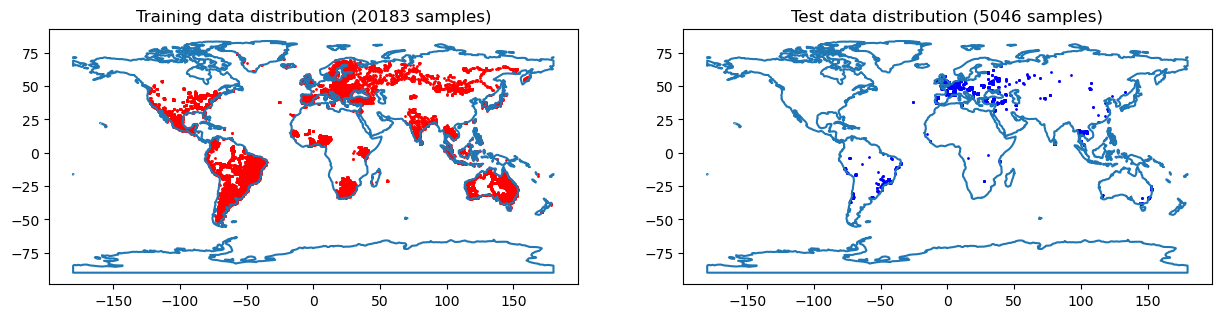

In [3]:
import geopandas as gpd
import geodatasets as gds

def plot_test_train_distribution(df_train, df_test):
    # create a GeoDataFrame from the DataFrame
    gdf_train = gpd.GeoDataFrame(df_train, geometry=gpd.points_from_xy(df_train.longitude, df_train.latitude))
    gdf_test = gpd.GeoDataFrame(df_test, geometry=gpd.points_from_xy(df_test.longitude, df_test.latitude))

    # Load a world map
    world = gpd.read_file(gds.get_path('naturalearth.land'))

    # Plot two world maps with the training and test data in one figure
    fig, ax = plt.subplots(1, 2, figsize=(15,15))
    world.boundary.plot(ax=ax[0])
    gdf_train.plot(ax=ax[0], color='red', markersize=1)
    ax[0].set_title(f'Training data distribution ({len(df_train)} samples)')
    world.boundary.plot(ax=ax[1])
    gdf_test.plot(ax=ax[1], color='blue', markersize=1)
    ax[1].set_title(f'Test data distribution ({len(df_test)} samples)')
    plt.show()

plot_test_train_distribution(df_train, df_test)


> We can immediately notice a problem with the distribution of the data sets, a lot of the test data seems to be of Germany and The Netherlands. This indicates that the data needs to be shuffled before it is chunked

### **2.1.1 Shuffling data batches**
Lets see if shuffling the data has an effect on the distribution. Because the images are labeled by their row index, they should be included in the dataset as well before shuffling. Otherwise coordinates will be matched with the wrong image

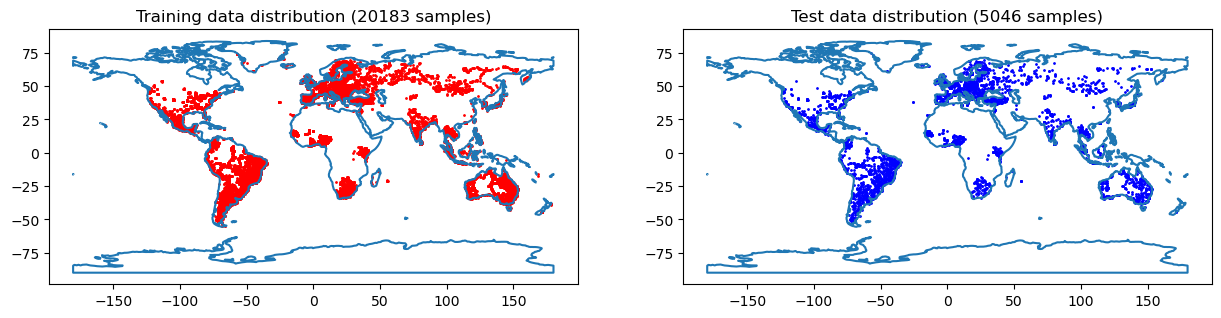

In [4]:
# Add a column 'filename' to the DataFrame ({index}.png)
df['filename'] = df.index.astype(str) + '.png'

# Shuffle the dataframe
df = df.sample(frac=1).reset_index(drop=True)

# Divide the data into training and test sets
df_train = df[:int(0.8*len(df))]
df_test = df[int(0.8*len(df)):]

# Check if the distribution of the training and test data is better now
plot_test_train_distribution(df_train, df_test)

> We can immediately see that the distribution is a lot better now. This will prevent the model to be overfit for certain regions

### **2.1.3 Saving the data batches**
After shuffling the data we can save the batches to their own CSV files. These files will be used to train and evaluate the model(s)

In [5]:
# Save the dataframes to CSV files
df_train.to_csv('data/coordinates_train.csv', index=False)
df_test.to_csv('data/coordinates_test.csv', index=False)

print(f'Training data saved to data/coordinates_train.csv')
print(f'Test data saved to data/coordinates_test.csv')

Training data saved to data/coordinates_train.csv
Test data saved to data/coordinates_test.csv
